In [1]:
import logging
from IPython.display import Markdown, display

import scarf
from scarf import cytebase

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)
# HF retry messages include private bucket URLs; keep them out of shared outputs.
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
# Connect to the public Cytebase catalog.
catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
# Search the catalog for the dataset used in this example.
matches = catalog.search("wilson kidney cortex")
# Stop if the expected kidney dataset is not available.
if not matches:
    raise RuntimeError("The example kidney dataset is not ready in this bucket")
# Summarize dataset titles and sizes while keeping full IDs in the result rows.
match_preview = matches.to_markdown(
    columns=["cytebase_id", "title", "cell_count"], max_cell_chars=32
)
# Display the search summary before choosing a dataset.
display(Markdown(match_preview))

| Cytebase ID | Title | Cells |
| --- | --- | ---: |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex… | Human kidney cortex snRNA-seq d… | 39,176 |

1 row. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [3]:
# Keep the dataset identifier returned by the catalog.
dataset_id = matches[0]["cytebase_id"]
# Read the dataset's scientific metadata and citation.
entry = catalog.dataset(dataset_id)
# Inspect the dataset record and source citation.
entry

### Human kidney cortex snRNA-seq data from donors with and without diabetic kidney disease

- **Cytebase ID:** `wilson_2022_human_kidney_cortex_snrna_diabetic_kidney_disease_e067e5ca`
- **Citation:**
    - Publication: https://doi.org/10.1038/s41467-022-32972-z
    - Dataset Version: https://datasets.cellxgene.cziscience.com/473d2e1c-a579-4682-96aa-b5b166d7b23e.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **DOI:** 10.1038/s41467-022-32972-z
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **Explorer:** https://cellxgene.cziscience.com/e/e067e5ca-e53e-485f-aa8e-efd5435229c8.cxg/
- **Size:** 39,176 cells, 35,469 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** 10x 3' v3, 10x 5' v1
- **Tissues:** cortex of kidney
- **Diseases:** normal, type 2 diabetes mellitus
- **Suspension:** nucleus
- **Source embeddings:** X_harmony, X_pca, X_umap

In [4]:
# Open the datastore for the following analysis.
ds = catalog.open_datastore(entry.id)
# Inspect the store's assays and dimensions.
ds

DataStore has 39176 (39176) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'assay', 'assay_ontology_term_id', 'author_cell_type', 
            'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 
            'disease_ontology_term_id', 'donor_id', 'doublet_id', 'is_primary_data', 'library_uuid', 
            'mapped_reference_annotation', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 
            'observation_joinid', 'percent.mt', 'percent.rpl', 'percent.rps', 'reported_diseases', 
            'sample_preservation_method', 'sample_uuid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'seurat_clusters', 
            'sex', 'sex_ontology_term_id', 'suspension_type', 'suspension_uuid', 'tissue', 
            'tissue_ontology_term_id', 'tissue_type'
   RNA assay has 35469 features 

In [5]:
# List the embeddings recorded in the source dataset.
print("Source embedding keys:", entry.source_embeddings())
# List the embeddings actually imported into the Scarf store.
print("Imported embedding keys:", sorted(cytebase.embeddings(ds)))
# Select the imported UMAP without recomputing its coordinates.
umap_ref = cytebase.embedding(ds, "X_umap")

Source embedding keys: ['X_harmony', 'X_pca', 'X_umap']


Imported embedding keys: ['X_umap']


In [6]:
import pandas as pd

# Choose the metadata fields needed for exploration.
wanted = ["cell_type", "tissue", "disease", "donor_id", "sex", "assay"]
# Keep only metadata fields available in this store.
columns = [column for column in wanted if column in ds.cells.columns]
# Read cell metadata and index it by cell ID.
meta = ds.cells.to_pandas_dataframe(["ids", *columns], key="I").set_index("ids")
# Preview cell types and donor groups without truncating annotation names.
with pd.option_context("display.max_colwidth", None):
    display(meta[["cell_type", "disease", "donor_id"]].head())

,cell_type,disease,donor_id
ids,,,
AAACCTGAGTGTTAGA-1,epithelial cell of proximal tubule,normal,control_1
AAACCTGCAAGCGCTC-1,kidney loop of Henle thick ascending limb epithelial cell,normal,control_1
AAACCTGCACCAGATT-1,kidney loop of Henle thick ascending limb epithelial cell,normal,control_1
AAACCTGCAGTCAGAG-1,epithelial cell of proximal tubule,normal,control_1
AAACCTGCATGGAATA-1,kidney distal convoluted tubule epithelial cell,normal,control_1


In [7]:
# Count cells assigned to each published cell type.
meta["cell_type"].value_counts().rename("cells").to_frame()

,cells
cell_type,
epithelial cell of proximal tubule,11478
kidney distal convoluted tubule epithelial cell,8469
kidney loop of Henle thick ascending limb epithelial cell,7749
renal principal cell,3295
renal alpha-intercalated cell,2029
endothelial cell,1702
parietal epithelial cell,1103
podocyte,1069
kidney loop of Henle thin ascending limb epithelial cell,679


In [8]:
# Compare the cell counts or fractions across the selected groups.
pd.crosstab(meta["cell_type"], meta["disease"])

disease,normal,type 2 diabetes mellitus
cell_type,,
endothelial cell,1167,535
epithelial cell of proximal tubule,8818,2660
fibroblast,210,128
kidney distal convoluted tubule epithelial cell,6099,2370
kidney loop of Henle thick ascending limb epithelial cell,5432,2317
kidney loop of Henle thin ascending limb epithelial cell,324,355
leukocyte,54,156
mesangial cell,268,117
parietal epithelial cell,696,407


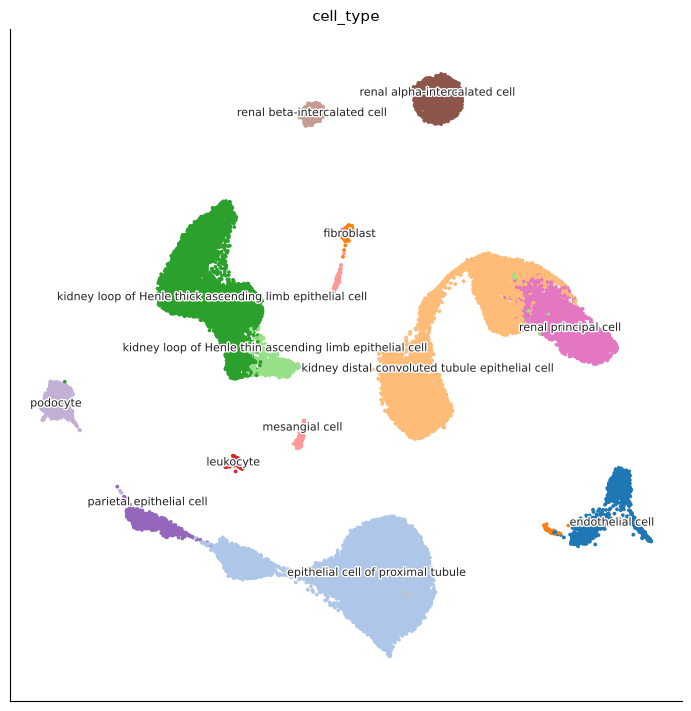

In [9]:
# Plot the published cell types and retain the figure for export.
cell_type_plot = ds.plots.embedding(
    layout=umap_ref, color_by="cell_type", figsize=(10, 7)
)

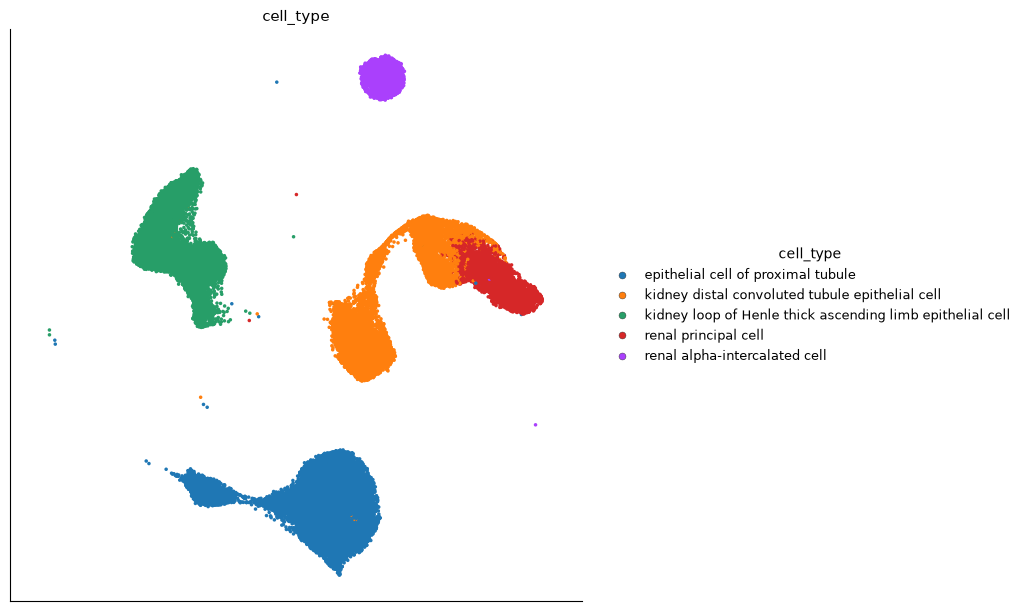

In [10]:
# Select the five most common cell types for a closer view.
top_types = meta["cell_type"].value_counts().head(5).index.tolist()
# Focus the UMAP on the five most abundant cell types.
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell_type",
    groups=top_types,
    figsize=(10, 6),
)

In [11]:
# Choose representative markers for the kidney populations.
genes = ["UMOD", "SLC34A1", "NPHS1", "PECAM1"]

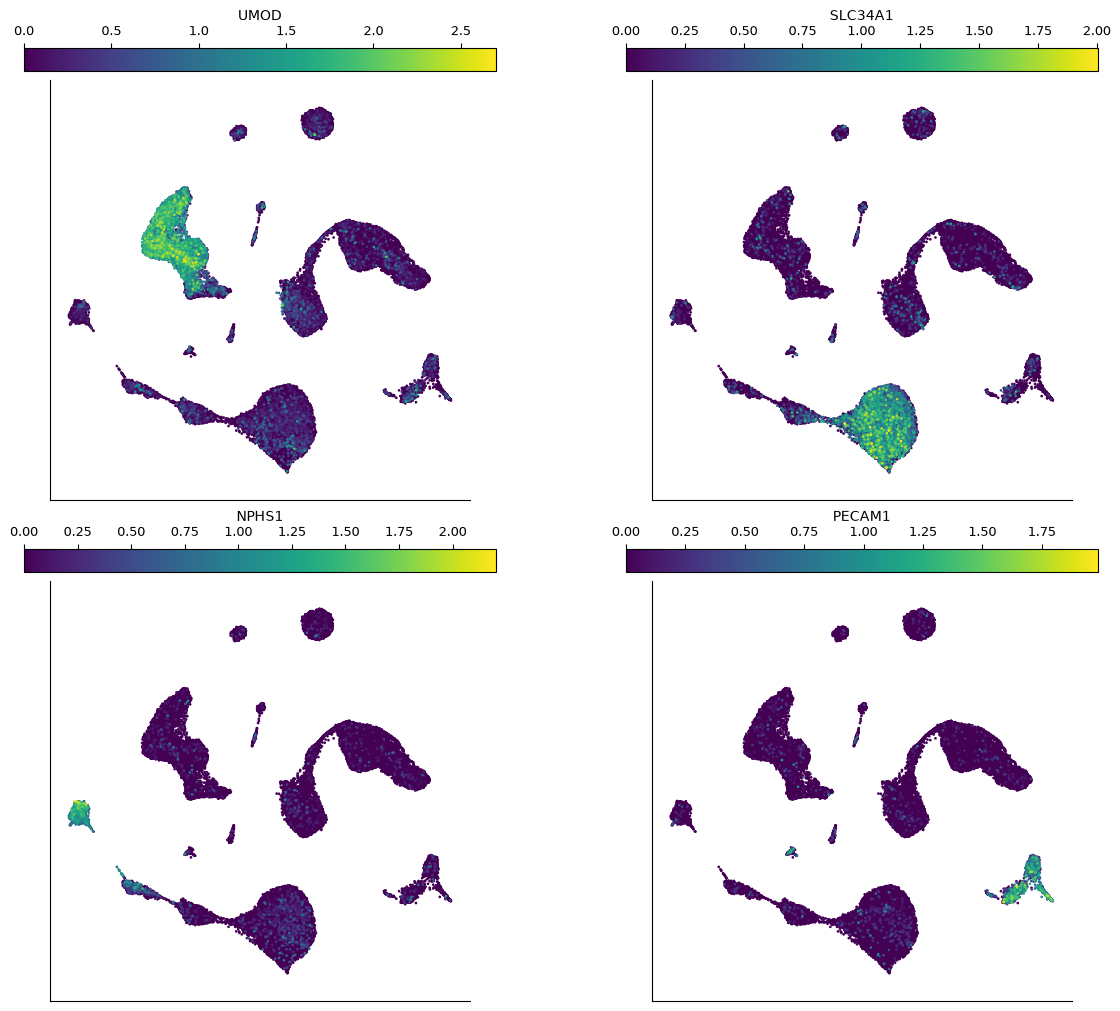

In [12]:
from scarf.plotting import NormalizationSpec

# Plot the four kidney markers using log-normalized expression.
ds.plots.embedding(
    layout=umap_ref,
    color_by=genes,
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    n_columns=2,
    figsize=(12, 10),
)

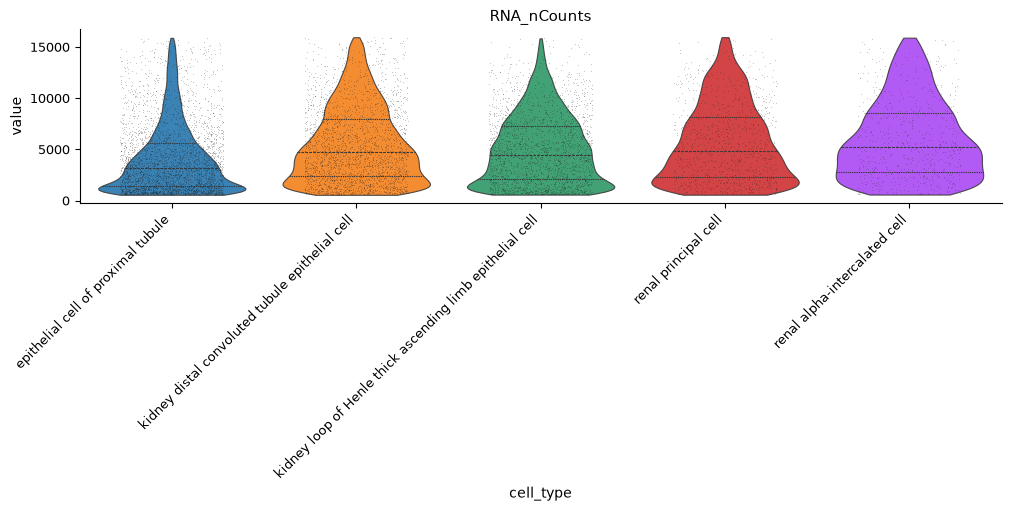

In [13]:
from scarf.plotting import CellField

# Compare distributions within the stated groups.
ds.plots.distribution(
    "RNA_nCounts",
    grouping=CellField("cell_type"),
    groups=top_types,
    figsize=(10, 5),
)

In [14]:
# Read coordinates indexed by the embedding's cell IDs.
coords = cytebase.embedding_coordinates(ds, umap_ref)
# Align metadata and coordinates by cell ID.
frame = coords.join(meta)
# Preview joined coordinates and full cell-type names in the same rows.
with pd.option_context("display.max_colwidth", None):
    display(frame[["umap_1", "umap_2", "cell_type"]].head())

,umap_1,umap_2,cell_type
ids,,,
AAACCTGAGTGTTAGA-1,-0.523972,-8.470732,epithelial cell of proximal tubule
AAACCTGCAAGCGCTC-1,-7.073731,3.068685,kidney loop of Henle thick ascending limb epithelial cell
AAACCTGCACCAGATT-1,-6.279858,4.984632,kidney loop of Henle thick ascending limb epithelial cell
AAACCTGCAGTCAGAG-1,0.838804,-11.116598,epithelial cell of proximal tubule
AAACCTGCATGGAATA-1,3.573810,5.386316,kidney distal convoluted tubule epithelial cell


In [15]:
from pathlib import Path

# Choose a local folder for exported figures.
out = Path("figures")
# Create the local folder if it does not already exist.
out.mkdir(exist_ok=True)
# Save the existing figure without repeating its data reads.
cell_type_plot.save(out / "cytebase_cell_types.png", dpi=150)
# Close the figure or reader after its final use.
cell_type_plot.close()
# Show the local filename of the exported figure.
print("Saved figures/cytebase_cell_types.png")

Saved figures/cytebase_cell_types.png


In [16]:
# List the catalog labels available for an exact search.
catalog.list_terms("disease")

| Label | Ontology ID | Datasets |
| --- | --- | ---: |
| Alzheimer disease | MONDO:0004975 | 9 |
| B-cell acute lymphoblastic leukemia | MONDO:0004947 | 2 |
| B-cell non-Hodgkin lymphoma | MONDO:0015759 | 3 |
| Barrett esophagus | MONDO:0013662 | 1 |
| COVID-19 | MONDO:0100096 | 54 |
| Crohn disease | MONDO:0005011 | 11 |
| DMD-related muscular dystrophy | MONDO:0700285 | 8 |
| Down syndrome | MONDO:0008608 | 1 |
| Ewing sarcoma | MONDO:0012817 | 1 |
| HER2 positive breast carcinoma | MONDO:0006244 | 5 |
| HIV infectious disease | MONDO:0005109 | 1 |
| HIV infectious disease &#124;&#124; leishmaniasis | MONDO:0005109 &#124;&#124; MONDO:0011989 | 1 |
| HIV infectious disease &#124;&#124; visceral leishmaniasis | MONDO:0005109 &#124;&#124; MONDO:0005445 | 2 |
| Lewy body dementia | MONDO:0007488 | 8 |
| Parkinson disease | MONDO:0005180 | 10 |
| Pick disease | MONDO:0008243 | 1 |
| Plasmodium malariae malaria | MONDO:0001943 | 1 |
| Sjogren syndrome | MONDO:0010030 | 12 |
| T-cell childhood acute lymphocytic leukemia | MONDO:0000871 | 2 |
| Wilms tumor | MONDO:0006058 | 1 |

Showing 20 of 322 rows. Use `to_markdown(max_rows=None)` to display all rows.

In [17]:
# Use an exact tissue label supplied by the catalog.
tissue = matches[0]["tissue_labels"][0]
# Find datasets using the exact tissue and organism labels.
kidney_datasets = catalog.find_datasets(tissue=tissue, organism="Homo sapiens")
# Summarize dataset sizes and disease labels with shortened display IDs.
kidney_preview = kidney_datasets.to_markdown(
    columns=["cytebase_id", "cell_count", "disease_labels"], max_cell_chars=32
)
# Display the exact-match search results.
display(Markdown(kidney_preview))

| Cytebase ID | Cells | Diseases |
| --- | ---: | --- |
| lake&#95;2025&#95;single&#95;nucleus&#95;rna&#95;se… | 1,388,643 | acute kidney injury, chronic ki… |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;… | 1,136,218 | normal |
| aceramateos&#95;2025&#95;multimodal&#95;ben… | 97,125 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 40,436 | normal |
| stewart&#95;2019&#95;mature&#95;kidney&#95;data… | 40,268 | normal |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex… | 39,176 | normal, type 2 diabetes mellitus |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 38,024 | normal |
| aceramateos&#95;2025&#95;multimodal&#95;ben… | 37,717 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 29,921 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 29,769 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 28,422 | normal |
| mcevoy&#95;2022&#95;living&#95;donor&#95;kidney… | 27,675 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 27,036 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 25,741 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 25,166 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,857 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,510 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,145 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 20,245 | normal |
| muto&#95;2021&#95;single&#95;cell&#95;transcrip… | 19,985 | normal |

Showing 20 of 30 rows. Use `to_markdown(max_rows=None)` to display all rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [18]:
# Run the parameterized catalog query on the local metadata copy.
small_datasets = catalog.query(
    """
    SELECT cytebase_id, first_author, year, cell_count, n_genes,
           len(cell_type_labels) AS n_cell_types
    FROM datasets
    WHERE status = ? AND processed_version_id = latest_version_id
      AND zarr_uri IS NOT NULL
    ORDER BY cell_count
    LIMIT 10
    """,
    parameters=["ready"],
)
# Keep all query columns while shortening only their displayed values.
display(Markdown(small_datasets.to_markdown(max_cell_chars=24)))

| Cytebase ID | First Author | Year | Cells | Genes | N Cell Types |
| --- | --- | ---: | ---: | ---: | --- |
| johansen&#95;2023&#95;sstchodl&#95;… | Johansen | 2,023 | 301 | 18,736 | 1 |
| ng&#95;2026&#95;t&#95;cells&#95;small&#95;c… | Ng | 2,026 | 450 | 13,943 | 1 |
| sampath&#95;kumar&#95;2023&#95;mous… | Sampath Kumar | 2,023 | 499 | 18,877 | 2 |
| johansen&#95;2023&#95;l5et&#95;neoc… | Johansen | 2,023 | 563 | 18,736 | 1 |
| johansen&#95;2023&#95;endo&#95;neoc… | Johansen | 2,023 | 582 | 18,736 | 1 |
| johansen&#95;2023&#95;vlmc&#95;neoc… | Johansen | 2,023 | 637 | 18,736 | 1 |
| sampath&#95;kumar&#95;2023&#95;mous… | Sampath Kumar | 2,023 | 703 | 27,368 | 16 |
| duclos&#95;2019&#95;characteriz… | Duclos | 2,019 | 796 | 51,976 | 9 |
| szabo&#95;2021&#95;74&#95;years&#95;old… | Szabo | 2,021 | 810 | 32,393 | 8 |
| fujimoto&#95;2020&#95;mouse&#95;lym… | Fujimoto | 2,020 | 893 | 17,932 | 4 |

10 rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.